<a href="https://colab.research.google.com/github/dachshoon/Deeplearning_project1/blob/main/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bias-variance decomposition


A central result in 'classical' machine learning and statistics is known as the _bias-variance decomposition_. Let's flesh it out.

Consider the following regression problem in which we have $x\in\mathbb{R}^D$, $y\in\mathbb{R}$, and want to learn the conditional distribution $p(y\lvert x)$, or at least its mean $\mathbb{E}[y\lvert x]$, via some parametric function $f(x)$. Now, any finite training set of $N$ points drawn from $p$ will itself be a random variable:

$$
\mathcal{D}=\left\{\left(x^{(n)}, y^{(n)}\right) \big|\ (x, y) \sim p(x, y)\right\}_{n=1}^N.
$$

The bias-variance decomposition considers how the risk (expected loss under $p$ for a model $f$) depends on this random variable. Let's do the calculation first, then tease out the intuition.


The risk under the joint distribution $p(x,y)$ for a regression task using the square loss is given by

$$
\begin{aligned}
\mathbb{E}[\mathcal{L}]
  &\stackrel{\mathrm{(a)}}{=} \mathbb{E}_{xy}\mathbb{E}_{\mathcal{D}}\Big[\{y - f(x; \mathcal{D})\}^2\Big] \\
  &\stackrel{\mathrm{(b)}}{=} \mathbb{E}_{xy}\mathbb{E}_{\mathcal{D}}\Big[\{y - h(x) + h(x) - f(x; \mathcal{D})\}^2\Big] \\
  &\stackrel{\mathrm{(c)}}{=} \mathbb{E}_{xy}\Big[\{y - h(x)\}^2\Big]
     + \mathbb{E}_x\mathbb{E}_\mathcal{D}\Big[\{h(x) - f(x; \mathcal{D})\}^2\Big] \\
  &\stackrel{\mathrm{(d)}}{=} \mathbb{E}_{xy}\Big[\{y - h(x)\}^2\Big]
     + \mathbb{E}_x\mathbb{E}_\mathcal{D}\Big[
        \big\{h(x)
        - \mathbb{E}_\mathcal{D}[f(x;\mathcal{D})]
        + \mathbb{E}_\mathcal{D}[f(x;\mathcal{D})]
        -  f(x; \mathcal{D})\big\}^2
      \Big] \\
  &\stackrel{\mathrm{(e)}}{=} \mathbb{E}_{xy}\Big[\{y - h(x)\}^2\Big]
     + \mathbb{E}_x\Big[\big\{h(x) - \mathbb{E}_\mathcal{D}[f(x;\mathcal{D})]\big\}^2\Big]
     + \mathbb{E}_x\mathbb{E}_\mathcal{D}\Big[\big\{f(x; \mathcal{D}) - \mathbb{E}_\mathcal{D}[f(x;\mathcal{D})]\big\}^2\Big] \\
  &\stackrel{\mathrm{(f)}}{=} \underbrace{\int\int\{y - h(x)\}^2p(x,y)\mathrm{d}x\mathrm{d}y}_{\mathrm{noise}}
     + \underbrace{\int\{h(x) - \mathbb{E}_\mathcal{D}[f(x;\mathcal{D})]\big\}^2p(x)\mathrm{d}x}_{\mathrm{bias}^2}
     + \underbrace{\int\mathbb{E}_\mathcal{D}\Big[\big\{f(x; \mathcal{D}) - \mathbb{E}_\mathcal{D}[f(x;\mathcal{D})]\big\}^2\Big]p(x)\mathrm{d}x}_{\mathrm{variance}},
\end{aligned}
$$

reasoning:
* $\mathrm{(a)}$ expresses the fact that $f$ is a function of both its inputs $x$ and the dataset $\mathcal{D}$ it is trained on, which is a random variable.
* $\mathrm{(b)}$ uses the additive identity; here $h(x):=\mathbb{E}_y[y\lvert x]$ is the optimal hypothesis under the square loss,
* $\mathrm{(c)}$ follows by noting that the cross-term vanishes since $\mathbb{E}_{xy}[y-h(x)] = 0$,
* $\mathrm{(d)}$ and $\mathrm{(e)}$ follow by again using the additive identity and noting that the cross-term is zero, and
* $\mathrm{(f)}$ spells out the expectations in terms of the underlying marginals.

This decomposition tells us a few things:

- In all but the deterministic case, all expectation models will unsurprisingly incur non-zero risk from irreducible noise in the data.
- Models that don't have sufficient capacity/flexibility or that are poorly specified will incur non-zero risk in expectation due to bias ('underfitting') resulting from being unable to closely match $h(x)$.
- Models that 'overfit' to their datasets $\mathcal{D}$ will have high variance over all $\mathcal{D}$; this also contributes to the true risk.

## Simple demonstration

Let's make something like Figure 3.5 of Bishop. We draw our data from $p(x,y)$ defined by:

$$
p(x) = \mathcal{U}\left(-\frac{\pi}{2}, \frac{\pi}{2}\right) \\
p(y\lvert x) = \mathcal{N}\left(\sin(x), \sigma^2\right)
$$



In [ ]:
# @title Imports

import numpy as np
import pandas as pd
import plotnine as gg
import sklearn

gg.theme_set(gg.theme_bw());

In [ ]:
num_data = 100
noise_sigma = 0.2
base_size = 20

def generate_step_data(num_samples, sigma=0.2):
    centers = np.random.choice([-2.0, 2.0], size=num_samples)
    xs = centers + np.random.randn(num_samples) * 0.5
    true_ys = np.where(xs > 0, 1, -1)  # x > 0 이면 1, 아니면 -1
    ys = true_ys + sigma * np.random.randn(num_samples)
    return xs, ys

# 기저 함수(Basis function) 변환 적용
def get_features(x, feature_type, num_features=24):
    if feature_type == 'polynomial':
        return np.array([x**n for n in range(num_features)]).T
    elif feature_type == 'fourier':
        return np.array([np.sin(2*np.pi*n*x / num_features) for n in range(num_features)]).T
    elif feature_type == 'gaussian':
        return np.array([np.exp(-(x - (2*np.pi*n/num_features - np.pi))**2) for n in range(num_features)]).T
    else:
        raise ValueError("Invalid feature type")

In [ ]:
# @title Plot the data and its underlying distribution.

df = pd.DataFrame({'x': ,
                   'y': train_Y,
                   'h': np.sin(train_xs),
                   'std': noise_sigma,
                   })

p = (gg.ggplot(df)
     + gg.aes(x='x', y='h')
     + gg.geom_point(gg.aes(y='y'))
     + gg.geom_line(color='green', size=2)
     + gg.geom_ribbon(gg.aes(ymin='h - std', ymax='h + std'), alpha=0.2)
     + gg.geom_ribbon(gg.aes(ymin='h - 2 * std', ymax='h + 2 * std'), alpha=0.1)
     + gg.ggtitle(r"$p(x, y)$: Mean in green, $\sigma$ and 2$\sigma$ intervals in grey")
     + gg.xlab(r"$x$")
     + gg.ylab(r"$y$")
)
p

SyntaxError: expression expected after dictionary key and ':' (1910814186.py, line 3)

Let's let fit a linear model

$$f(x;\theta)=\theta^T\phi(x)$$

where $\theta\in\mathbb{R}^M$ are model weights and $\phi: \mathbb{R}\to\mathbb{R}^M$ are features. Some example features:

- Polynomial:
  $$\phi_P^m(x) = x^m$$
- Fourier:
  $$\phi_F^m(x) = \sin\left(\frac{2\pi m x}{M}\right)$$
- Gaussian: $$\phi_G^m(x) = \exp\left(-\left[x + \frac{M\pi - 2\pi m}{M}\right]^2\right)$$

We'll minimize the $l_2$-regularized empirical risk

$$
\hat{\mathcal{L}}= + \lambda\big\|\theta\big\|^2_2 + \sum_{n=1}^N \left(y^{(i)} - f\left(x^{(i)};\theta\right)\right)^2.
$$

In [ ]:
ratios = [(1, 1, 1), (2, 1, 1), (4, 1, 1), (8, 1, 1)]
feature_types = ['polynomial', 'fourier', 'gaussian']
lambdas = [1e-3, 1e-1, 1e0, 1e1]
print("2) p(x) => bimodal")
for ratio in ratios:
    # 3-1. 비율에 맞게 독립적인 데이터셋 생성
    train_size = base_size * ratio[0]
    val_size = base_size * ratio[1]
    test_size = base_size * ratio[2]

    train_set = generate_step_data(train_size, noise_sigma)
    val_set = generate_step_data(val_size, noise_sigma)
    test_set = generate_step_data(test_size, noise_sigma)

    print(f"{'='*60}")
    print(f"Hyperparameter Tuning with Validation Set / Ratio = {ratio}")

    best_val_mse = float('inf')
    best_params = {}
    best_model = None

    # 3-2. Validation을 통한 하이퍼파라미터 탐색
    for f_type in feature_types:
        for lam in lambdas:
            X_train_feat = get_features(train_set[0], f_type, num_features)
            X_val_feat = get_features(val_set[0], f_type, num_features)

            model = sklearn.linear_model.Ridge(alpha=lam)
            model.fit(X_train_feat, train_set[1])

            val_preds = model.predict(X_val_feat)
            val_mse = mean_squared_error(val_set[1], val_preds)


            if val_mse < best_val_mse:
                best_val_mse = val_mse
                best_params = {'feature': f_type, 'lam': lam}
                best_model = model
    print(f"Best Hyperparameter: Feature = '{best_params['feature']}', Lambda = {best_params['lam']}, MSE value : {best_val_mse:.4f}")

    # 3-3. 최적의 모델을 사용하여 Test 성능 평가
    X_test_feat = get_features(test_set[0], best_params['feature'], num_features)
    test_preds = best_model.predict(X_test_feat)
    test_mse = mean_squared_error(test_set[1], test_preds)

    print("=== Final Evaluation ===")
    print(f"Test MSE of the best model: {test_mse:.4f}")

2) p(x) => bimodal
Hyperparameter Tuning with Validation Set / Ratio = (1, 1, 1)
Best Hyperparameter: Feature = 'fourier', Lambda = 0.1, MSE value : 0.0462
=== Final Evaluation ===
Test MSE of the best model: 0.0892
Hyperparameter Tuning with Validation Set / Ratio = (2, 1, 1)
Best Hyperparameter: Feature = 'gaussian', Lambda = 0.001, MSE value : 0.0224
=== Final Evaluation ===
Test MSE of the best model: 0.0532
Hyperparameter Tuning with Validation Set / Ratio = (4, 1, 1)
Best Hyperparameter: Feature = 'fourier', Lambda = 0.1, MSE value : 0.0474
=== Final Evaluation ===
Test MSE of the best model: 0.0411
Hyperparameter Tuning with Validation Set / Ratio = (8, 1, 1)
Best Hyperparameter: Feature = 'gaussian', Lambda = 0.001, MSE value : 0.0401
=== Final Evaluation ===
Test MSE of the best model: 0.0490


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.41025e-27): result may not be accurate.
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.85322e-26): result may not be accurate.
/usr/local/lib/python3

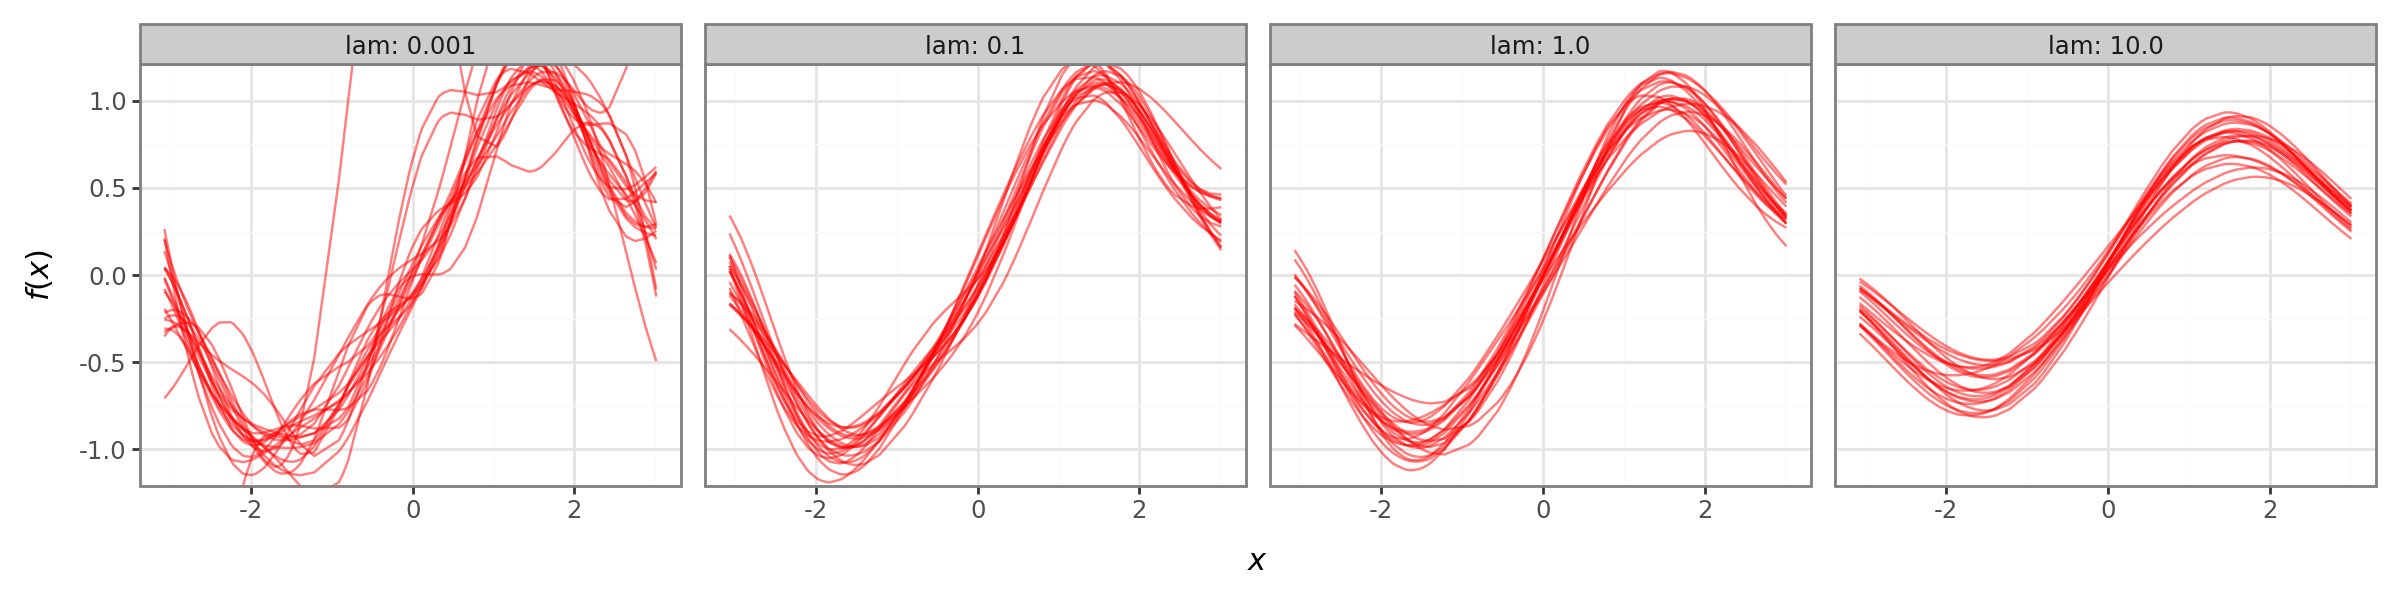

In [ ]:
# Plot our fitted functions.
fit_plot = (gg.ggplot(results_df)
            + gg.aes(x='x')

            + gg.geom_line(gg.aes(y='f', group='idx'), color='red', alpha=0.5)
            + gg.facet_wrap('lam', labeller='label_both', ncol=4)
            + gg.coord_cartesian(ylim=[-1.1, 1.1])
            + gg.theme(figure_size=(12, 3))
            + gg.xlab(r'$x$')
            + gg.ylab(r'$f(x)$')
)
fit_plot

In [ ]:
# Plot their mean, over the datasets D.
mean_df = results_df.groupby(['x', 'lam', 'y', 'h']).agg({'f': "mean"}).reset_index()

mean_plot = (gg.ggplot(mean_df)
             + gg.aes(x='x', y='f')
             + gg.geom_line(gg.aes(y='h'), color='green')
             + gg.geom_line(color='red')
             + gg.facet_wrap('lam', labeller='label_both', ncol=4)
             + gg.theme(figure_size=(12, 3))
             + gg.xlab(r'$x$')
             + gg.ylab(r'$\mathbb{E}_\mathcal{D}f(x)$')
)
mean_plot

NameError: name 'results_df' is not defined

## Homework

Homework tasks are as follows and you should submit a report with appropriate screen captures to show you have done them:
*   The above codes are only for visualizing the bias-variance decomposition in our lecture slides. You need to extend this toward a more authentic machine learning pipeline, i.e., train -> validation -> test.
*   Create a validation and a test set, and you need to choose the best hyperparameter combinations "lam", i.e., the Ridge's most important hyperparameter, and "features", i.e., the non-linear basis function, via validation. For creating the validation and test sets, you can use the same $p(x)$ and $p(y|x)$ models but sample independently from the train set. So, train with the train set, choose the best hyperparameter combinations (or equivalently, the best model) with the validatation set, and test with the test set. You should prepare the validation and test sets in the "Create the dataset" section above. One more thing is that you do not need to subsample the train set, i.e., num_models should be set to 1, and use the entire train set.
*   Repeat the above with at least three different various train/validation/test set sizes (or ratios), i.e., 5:3:2, 6:2:2, and 8:1:1.
*   Repeat the abote steps with your own complicated $p(x)$ and $p(y|x)$ definitions. No limitation for this. It is totally up to you how to define them.
*   Write your final undersanding about the regularization, validation, bias-variance decomposition.
*   Answer the following question in your report. Suppose you have to build a computer program to distinguish cat and dog images. You may accomplish this task with a series of long if-else statements. One can instead train a machine learning model after collecting cat and dog images. Critisize the learning-based method as much as you can.